In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.ndimage import gaussian_filter
from nilearn.glm.first_level import FirstLevelModel

import fusiproc_utils2 as fu

In [5]:
# -------- dataset paths -------
BASE = Path("/Users/clairenastaskin/data/sub-Forest001/2026-05-27/pathfinder.forest/events/resting_state/06a173f4-385f-712a-8000-ed6162964365")
RUN  = "pwd.nii"               # raw fUSI volume (change if needed)
PWD  = BASE / RUN

# -------- preprocessing switches ----
REG_REFERENCE = "mean"          # registration reference: {"mean", "median"}

SMOOTH_METHOD = "boxcar"        # temporal smoothing: {"none", "boxcar", "savgol"}
SMOOTH_WINDOW = 3               # for boxcar (odd)
SG_PARAMS     = dict(window=7, polyorder=2)  # for Savitzky–Golay

FD_THRESH  = 0.5                # mm — framewise displacement threshold
RADIUS_MM  = 50.0               # mm — sphere radius for FD

# -------- confound-regression switches (empty-events GLM) ----
# The empty-events FirstLevelModel regresses these nuisance signals (plus
# cosine drift) out of the cleaned run; its residuals become the connectivity
# input. The GLM also owns spatial smoothing (smoothing_fwhm) and the high-pass
# (high_pass + cosine drift), so the connectivity cell below skips those.
CONF_USE = {
    "motion_6":      False,   # 6 rigid params (mutually exclusive with motion_fsl24)
    "motion_fsl24":  True,    # Friston-24 expansion
    "extra_fd":      False,   # framewise displacement as a regressor
    "dvars_stdz":    False,   # standardized DVARS (needs reg_path/mask_path)
    "tcompcor":      False,   # temporal CompCor components
}
assert not (CONF_USE["motion_6"] and CONF_USE["motion_fsl24"]), (
    "motion_6 and motion_fsl24 are mutually exclusive"
)

GLM_SMOOTH_FWHM = 5             # mm — spatial smoothing done inside the GLM
GLM_HIGH_PASS   = 0.01          # Hz — high-pass (with cosine drift) inside the GLM

# Tag used in saved filenames
if SMOOTH_METHOD == "none":
    smooth_tag = "_nosmooth"
elif SMOOTH_METHOD == "boxcar":
    smooth_tag = f"_boxcar{SMOOTH_WINDOW}"
elif SMOOTH_METHOD == "savgol":
    smooth_tag = f"_savgol{SG_PARAMS['window']}-{SG_PARAMS['polyorder']}"
else:
    raise ValueError(f"Unknown SMOOTH_METHOD: {SMOOTH_METHOD}")

In [6]:
# Load ARIA logs and compute t_r as the mean inter-frame interval
logs_df = pd.read_parquet(BASE / "logs.parquet")
print(f"Loaded logs.parquet: shape {logs_df.shape}")

volume_timing_ns = float(np.mean(np.diff(logs_df["time_ns"].to_numpy())))
volume_timing_s  = volume_timing_ns / 1e9
t_r = volume_timing_s
np.save(BASE / "t_r.npy", t_r)
print(f"t_r = {t_r:.6f} s")

Loaded logs.parquet: shape (360, 14)
t_r = 2.001922 s


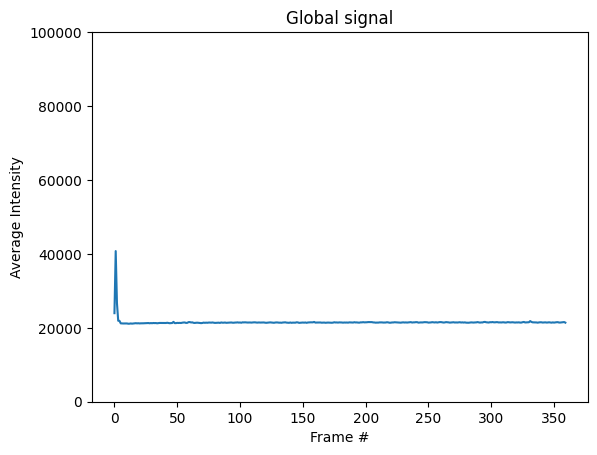

Data shape: (183, 88, 141, 360), mask voxels: 1237400 / 2270664


In [7]:
# Load fUSI data, build NaN-derived brain mask, compute global signal
data, affine, _ = fu.load_fusi_nifti(PWD)
mask = fu.nan_mask(data)
mask_path = fu.save_nifti(mask.astype(np.uint8), affine, BASE / "mask.nii.gz")

gs = fu.global_signal(data)
fu.plot_global_signal(gs, BASE / "global_signal.png", y_lim=[0, 1e5])
print(f"Data shape: {data.shape}, mask voxels: {int(mask.sum())} / {mask.size}")

## Censor high-intensity (motion) frames via the global signal

Drop the first two frames as warm-up, then flag frames whose global signal is
> k σ from the median.

Frames censored after global-signal step: [0, 1, 2, 3, 4, 47, 60, 159, 331]


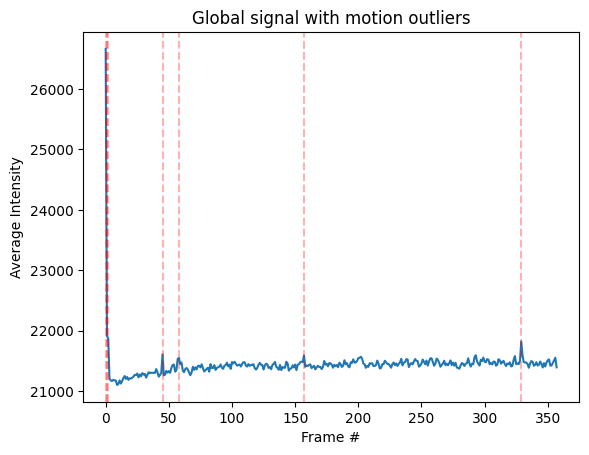

In [9]:
skip = {0, 1}  # initial frames to skip (e.g. for stabilization)
keep_mask = np.ones(len(gs), dtype=bool)
keep_mask[list(skip)] = False
gs_clean = gs[keep_mask]
kept_frames_gs = np.where(keep_mask)[0]

bad_gs, good_gs, fig = fu.detect_motion_via_global(gs_clean, t_r, k=4.0, y_lim=None)
fig.savefig(BASE / "global_signal_with_masked_frame.png")

# map bad indices back to original frame indices and update skip
skip.update(int(kept_frames_gs[i]) for i in bad_gs)
print(f"Frames censored after global-signal step: {sorted(skip)}")

In [10]:
## Rigid registration

# Register all kept frames to the chosen reference. Cached on disk in
# `BASE/registration/` — recompute only if the folder is missing.

In [11]:
registration_path = BASE / "registration"

if not registration_path.exists():
    registration_path.mkdir(exist_ok=True)
    data_f32 = np.where(np.isfinite(data), data, 0).astype(np.float32, copy=False)

    reg, rigid, metric, stop, kept_idx = fu.register_3d_image_stack(
        data_f32,
        reference=REG_REFERENCE,
        spacing=np.linalg.norm(affine[:3, :3], axis=0),
        skip_indices=skip,
        mask=mask,
        verbose=True,
    )
    del data_f32

    np.save(registration_path / "reg.npy", reg)
    np.save(registration_path / "rigid.npy", rigid)
    np.save(registration_path / "metric.npy", metric)
    np.save(registration_path / "stop.npy", stop)
    np.save(registration_path / "kept_idx.npy", kept_idx)
    np.save(registration_path / "skip.npy", np.array(sorted(skip), dtype=int))
    fu.save_doppler_movie(reg, registration_path / "Doppler_movie_after_rigid_registration.mp4")
else:
    reg      = np.load(registration_path / "reg.npy")
    rigid    = np.load(registration_path / "rigid.npy")
    metric   = np.load(registration_path / "metric.npy")
    stop     = np.load(registration_path / "stop.npy")
    kept_idx = np.load(registration_path / "kept_idx.npy")
print(f"reg shape: {reg.shape}, kept_idx: {len(kept_idx)} frames")

[frame    5] metric = -8.091112e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 11 iterations. Gradient magnitude (9.56391e-05) is less than gradient magnitude tolerance (0.0001).
[frame    6] metric = -8.189088e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 10 iterations. Gradient magnitude (7.81524e-05) is less than gradient magnitude tolerance (0.0001).
[frame    7] metric = -8.235676e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 10 iterations. Gradient magnitude (7.07544e-05) is less than gradient magnitude tolerance (0.0001).
[frame    8] metric = -8.185886e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 10 iterations. Gradient magnitude (7.73385e-05) is less than gradient magnitude tolerance (0.0001).
[frame    9] metric = -8.102038e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance 

/Users/clairenastaskin/Documents/Anise/Experiments/fusiproc_utils2.py:439: RuntimeWarning: divide by zero encountered in log10
  data_db = 10*np.log10(reg_data)
Animation size has reached 21015282 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


reg shape: (183, 88, 141, 351), kept_idx: 351 frames


## Framewise displacement (FD) censoring

Compute FD on the registered series, drop frames above `FD_THRESH`, then
NaN-pad the registration outputs back to the original number of frames.

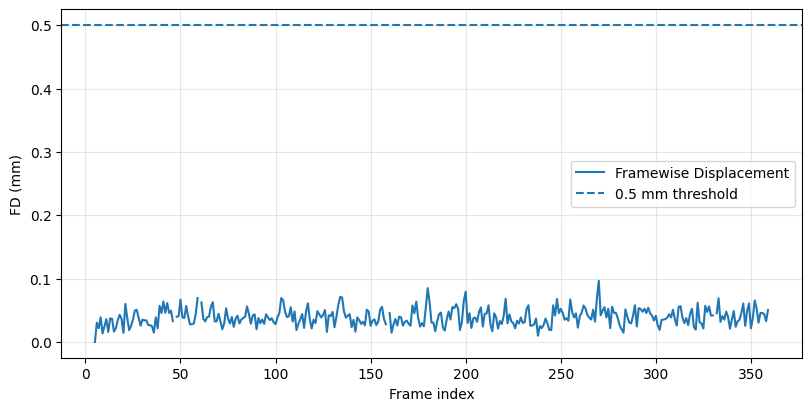

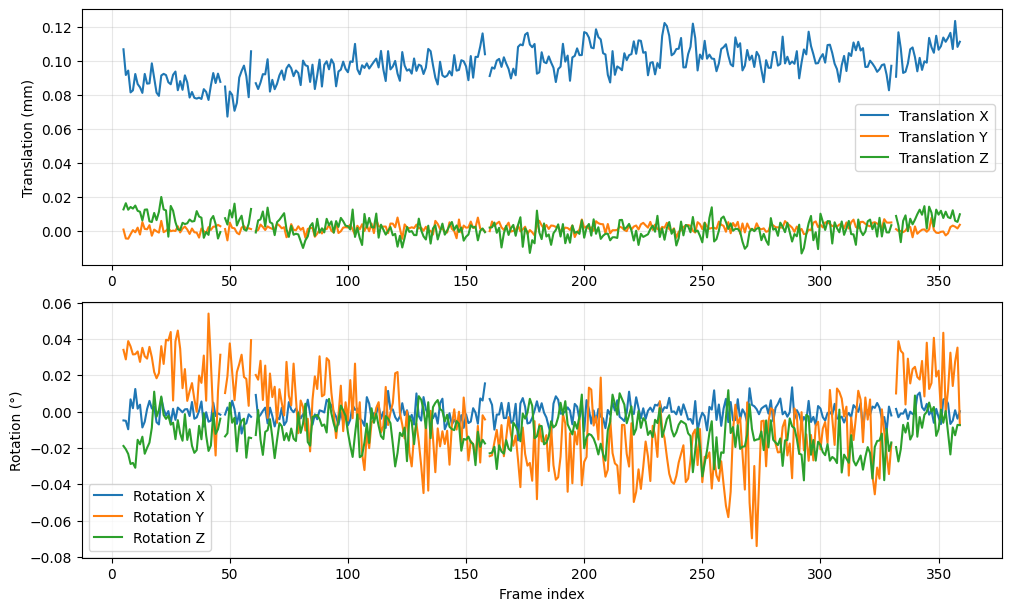

Frames retained after FD censoring: 351 / 360


In [12]:
n_frames = data.shape[-1]

fd = fu.framewise_displacement(rigid, radius_mm=RADIUS_MM)
fd_full = np.full(n_frames, np.nan)
fd_full[kept_idx] = fd

bad_fd = fu.plot_fd(fd_full, FD_THRESH, BASE / "framewise_displacement.png")
fd_tag = f"{FD_THRESH:g}".replace(".", "p")
np.savetxt(BASE / f"fd_over_{fd_tag}_indices.txt", bad_fd, fmt="%d")

skip.update(int(i) for i in bad_fd)

# Drop newly censored frames from the registered outputs
keep_after_all = [i for i in kept_idx if i not in skip]
sel = np.isin(kept_idx, keep_after_all)
reg_use    = reg[..., sel]
rigid_use  = rigid[:, sel]
metric_use = metric[sel]
stop_use   = [s for s, ok in zip(stop, sel) if ok]

# NaN-pad back to full length
reg_full, rigid_full, metric_full, stop_full = fu.reinstate_nans(
    reg_use, rigid_use, metric_use, stop_use, n_frames, keep_after_all,
)

fu.plot_registration_parameters(rigid_full, registration_path / "registration.png")
print(f"Frames retained after FD censoring: {len(keep_after_all)} / {n_frames}")

## Temporal smoothing → save cleaned run

Apply boxcar / Savitzky–Golay (or none), save the cleaned 4D run as
`fusi_run_clean.nii.gz`, and use it as the input for connectivity analysis.

In [13]:
import gc

if SMOOTH_METHOD == "none":
    smoothed = reg_full.copy()
elif SMOOTH_METHOD == "boxcar":
    smoothed = fu.boxcar_smooth(reg_full, SMOOTH_WINDOW)
elif SMOOTH_METHOD == "savgol":
    smoothed = fu.savgol_smooth(reg_full, **SG_PARAMS)
else:
    raise ValueError(f"Unknown SMOOTH_METHOD “{SMOOTH_METHOD}”")

# Cleaned (registered + temporally smoothed) run. Kept in `clean_img` because it
# is the input the empty-events GLM residualizes in the next cells.
clean_img = nib.Nifti1Image(np.nan_to_num(smoothed), affine)
clean_img.to_filename(BASE / "fusi_run_clean.nii.gz")
fu.save_nifti(clean_img.get_fdata().mean(axis=-1).astype(np.float32), affine,
              BASE / "fusi_run_clean_mean.nii.gz")

# Frames surviving every censoring step — passed to Nilearn as the sample mask so
# the GLM is fit only on retained timepoints.
sample_mask = np.array(keep_after_all, dtype=int)
np.save(BASE / "fusi_indices_retained_volumes.npy", sample_mask)

nx, ny, nz, nt = smoothed.shape
print(f"Clean data shape: {smoothed.shape}, retained frames: {len(sample_mask)} / {nt}")

/Users/clairenastaskin/Documents/Anise/Experiments/fusiproc_utils2.py:343: RuntimeWarning: Mean of empty slice
  out[..., t] = np.nanmean(data[..., lo:hi], axis=3)


Clean data shape: (183, 88, 141, 360), retained frames: 351 / 360


## Confound regression (Friston-24 + GIR) via empty-events GLM

Build a nuisance design from the motion parameters (Friston-24 by default),
optional FD / DVARS / tCompCor, and a global-intensity regressor, then fit an
**empty-events** `FirstLevelModel` that models only cosine drift + these
confounds (no task). Its residuals — additionally spatially smoothed and
high-passed inside the GLM — become the `data_clean` series the connectivity
steps below operate on.

This is resting-state, so no task events are loaded; the SQLite event-reading
step from the EV/GLM pipeline is intentionally dropped. Because the GLM owns the
spatial smoothing and high-pass, the connectivity cell **skips** its own
Gaussian smoothing and Butterworth high-pass.

In [14]:
# ------------------------------------------------------------------
# Build confounds – all arrays must have n_frames rows
# ------------------------------------------------------------------
conf_list = []

# ── Motion regressors ───────────────────────────────────
motion_full = rigid_full.T.copy()  # (n_frames, 6) – tx,ty,tz,rotx,roty,rotz
motion_full[np.isnan(motion_full)] = 0

if CONF_USE["motion_fsl24"]:
    # --- FSL-24 (Friston-24) construction ---
    # First derivative (frame-to-frame change) of the 6 motion parameters.
    deriv = np.vstack([np.zeros((1, 6)), np.diff(motion_full, axis=0)])
    # Quadratic terms: squares of the parameters and their derivatives.
    quad = np.square(np.hstack([motion_full, deriv]))  # 12 quadratic terms
    # 6 params + 6 derivatives + 12 quadratics = 24 regressors.
    fsl24 = np.hstack([motion_full, deriv, quad])
    labels = (
        [f"{p}" for p in ("tx", "ty", "tz", "rotx", "roty", "rotz")]
        + [f"d{p}" for p in ("tx", "ty", "tz", "rotx", "roty", "rotz")]
        + [f"{p}2" for p in ("tx", "ty", "tz", "rotx", "roty", "rotz")]
        + [f"d{p}2" for p in ("tx", "ty", "tz", "rotx", "roty", "rotz")]
    )
    conf_list.append(pd.DataFrame(fsl24, columns=labels))

elif CONF_USE["motion_6"]:
    # Original 6 motion parameters (translations + rotations).
    conf_list.append(
        pd.DataFrame(motion_full, columns=["tx", "ty", "tz", "rotx", "roty", "rotz"])
    )

# Framewise displacement (FD): sum of absolute differentiated realignment
# estimates; flags volumes with excessive head motion.
if CONF_USE["extra_fd"]:
    fd_col = fd_full.copy()           # already n_frames long
    fd_col[np.isnan(fd_col)] = 0
    conf_list.append(pd.DataFrame(fd_col, columns=["fd"]))

# DVARS: RMS variance of the temporal derivative of each volume; captures
# signal changes from motion/artifacts. Requires `dvars_stdz` (compute via
# fu.calc_dvars on a saved registered NIfTI before this cell).
if CONF_USE["dvars_stdz"]:
    dvars_full = np.full(n_frames, np.nan)
    dvars_full[kept_idx] = dvars_stdz
    dvars_full[np.isnan(dvars_full)] = 0
    conf_list.append(pd.DataFrame(dvars_full, columns=["dvars"]))

# tCompCor: PCA of high-variance (noise) voxels for physiological/other
# non-motion nuisance regression. Requires `tc_out` from fu.run_tcompcor.
if CONF_USE["tcompcor"]:
    comps = pd.read_csv(tc_out["components"], sep="\t").to_numpy()
    tcomp_full = np.full((n_frames, comps.shape[1]), 0.0)
    tcomp_full[kept_idx] = comps
    conf_list.append(
        pd.DataFrame(tcomp_full, columns=[f"tCompCor{i:02d}" for i in range(comps.shape[1])])
    )

# GIR — global intensity regressor: within-mask mean of the cleaned (registered
# + smoothed) series, appended as an extra confound.
global_intensity = np.nan_to_num(np.nanmean(smoothed[mask], axis=0))
conf_list.append(pd.DataFrame(global_intensity, columns=["global_intensity"]))

# -- final dataframe -----------------------------------------------------------
confounds_df = pd.concat(conf_list, axis=1)
print(f"Confounds matrix: {confounds_df.shape[0]} frames × {confounds_df.shape[1]} regressors")
print("Columns:", list(confounds_df.columns))

Confounds matrix: 360 frames × 25 regressors
Columns: ['tx', 'ty', 'tz', 'rotx', 'roty', 'rotz', 'dtx', 'dty', 'dtz', 'drotx', 'droty', 'drotz', 'tx2', 'ty2', 'tz2', 'rotx2', 'roty2', 'rotz2', 'dtx2', 'dty2', 'dtz2', 'drotx2', 'droty2', 'drotz2', 'global_intensity']


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_8915/241247653.py:60: RuntimeWarning: Mean of empty slice
  global_intensity = np.nan_to_num(np.nanmean(smoothed[mask], axis=0))


In [15]:
# Empty-events FirstLevelModel: models ONLY cosine drift + the nuisance
# confounds above (no task regressors), then we pull its residuals as the
# denoised series that connectivity consumes downstream. The GLM also performs
# the spatial smoothing (smoothing_fwhm) and the high-pass (high_pass + cosine
# drift), so the connectivity cell below skips both.
empty_events = pd.DataFrame({"onset": [], "duration": [], "trial_type": []})

glm = FirstLevelModel(
    t_r=volume_timing_s,
    hrf_model="glover",
    drift_model="cosine",
    high_pass=GLM_HIGH_PASS,
    noise_model="ols",          # OLS is the cleanest choice for residualization
    standardize=True,
    smoothing_fwhm=GLM_SMOOTH_FWHM,
    mask_img=nib.Nifti1Image(mask.astype(np.uint8), affine),
    minimize_memory=False,      # required so glm.residuals is populated
)

glm, design = fu.build_design_matrix(glm, empty_events, confounds_df, sample_mask, clean_img)
np.savez(
    BASE / "design_matrix.npz",
    design_matrix=design.values,
    column_names=design.columns,
)
print(f"Design matrix: {design.shape[0]} retained frames × {design.shape[1]} regressors")
print("Regressors:", list(design.columns))

# Residuals from the empty-events OLS fit (one volume per retained frame),
# re-padded to the full time axis so downstream indexing stays aligned.
resid_kept = np.asarray(glm.residuals[0].get_fdata(), dtype=np.float32)
filtered_data = np.zeros((nx, ny, nz, nt), dtype=np.float32)
filtered_data[..., sample_mask] = resid_kept

clean_img = nib.Nifti1Image(filtered_data, affine)
clean_img.to_filename(BASE / f"fusi_run_residualized{smooth_tag}.nii.gz")

# Hand the residualized series to the connectivity pipeline as `data_clean`,
# then free the large preprocessing intermediates to keep peak RAM in check.
reg_full   = filtered_data            # kept for parity with the EV pipeline naming
data_clean = filtered_data
for _v in ("smoothed", "resid_kept", "reg", "reg_use", "data", "glm"):
    globals().pop(_v, None)
gc.collect()

print(f"Residualized data shape: {data_clean.shape}, dtype: {data_clean.dtype} "
      f"(~{data_clean.nbytes / 1e9:.2f} GB)")

Design matrix: 351 retained frames × 40 regressors
Regressors: ['tx', 'ty', 'tz', 'rotx', 'roty', 'rotz', 'dtx', 'dty', 'dtz', 'drotx', 'droty', 'drotz', 'tx2', 'ty2', 'tz2', 'rotx2', 'roty2', 'rotz2', 'dtx2', 'dty2', 'dtz2', 'drotx2', 'droty2', 'drotz2', 'global_intensity', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'drift_7', 'drift_8', 'drift_9', 'drift_10', 'drift_11', 'drift_12', 'drift_13', 'drift_14', 'constant']
Residualized data shape: (183, 88, 141, 360), dtype: float32 (~3.27 GB)


## Connectivity-specific preprocessing

The empty-events GLM already applied spatial smoothing and the high-pass, so
here we only **demean per voxel** and **apply the brain mask** to produce the
unit-base time-courses fed to SVD and seed correlation.

> To instead do smoothing/high-pass at this stage, set `GLM_SMOOTH_FWHM=None`
> and `GLM_HIGH_PASS=None` in the config cell and restore the
> `gaussian_filter` + Butterworth block here.

In [16]:
# Spatial smoothing and the high-pass were already done inside the empty-events
# GLM, so they are skipped here. Operate in place on the residualized series:
# demean per voxel along time, scrub non-finite values, and re-apply the mask.
data_norm = data_clean            # rename, no copy (residualized + GLM-denoised)
del data_clean

mean_t = data_norm.mean(axis=3, keepdims=True).astype(np.float32)
data_norm -= mean_t
del mean_t

np.nan_to_num(data_norm, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
data_norm *= mask[..., np.newaxis]
gc.collect()

print(f"data_norm shape: {data_norm.shape}, dtype: {data_norm.dtype} "
      f"(~{data_norm.nbytes / 1e9:.2f} GB) | "
      f"smoothing + high-pass applied in GLM "
      f"(fwhm={GLM_SMOOTH_FWHM} mm, high_pass={GLM_HIGH_PASS} Hz)")

data_norm shape: (183, 88, 141, 360), dtype: float32 (~3.27 GB) | smoothing + high-pass applied in GLM (fwhm=5 mm, high_pass=0.01 Hz)


## SVD

Reshape spatial dims to `(n_voxels, nt)` and compute the thin SVD directly.
Columns of `U` are spatial modes, `S` are singular values, rows of `Vt` are
temporal signatures.

In [17]:
# Full thin SVD on the (n_voxels, nt) matrix would materialize a U the same
# size as data_norm. Two cheaper steps instead:
#   1) restrict to in-mask voxels
#   2) SVD via the (nt × nt) Gram matrix X.T @ X (n_voxels >> nt here)

n_voxels  = nx * ny * nz
flat_mask = mask.reshape(-1)
X = data_norm.reshape(n_voxels, nt)[flat_mask]   # (n_in_mask, nt) float32
print(f"In-mask voxels for SVD: {X.shape[0]} / {n_voxels}")

gram = (X.T @ X).astype(np.float64)              # (nt, nt) — small
eigvals, V = np.linalg.eigh(gram)                # ascending order
order   = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
V       = V[:, order].astype(np.float32)
S       = np.sqrt(np.maximum(eigvals, 0)).astype(np.float32)
Vt      = V.T

# U on masked voxels, then scatter back into a full volume for visualization
U_masked  = (X @ V) / (S[np.newaxis, :] + 1e-12)
US_masked = U_masked * S[np.newaxis, :]
del U_masked, gram, X
gc.collect()

US = np.zeros((n_voxels, nt), dtype=np.float32)
US[flat_mask] = US_masked
US_vol = US.reshape(nx, ny, nz, nt)
del US_masked, US
gc.collect()

print(f"Top 5 singular values: {S[:5]}")

In-mask voxels for SVD: 1237400 / 2270664
Top 5 singular values: [2503.3616 1832.7053 1629.7897 1521.5623 1467.8623]


## SVD spatial modes

Show the first 16 modes on a middle slice, and save each mode as a NIfTI.

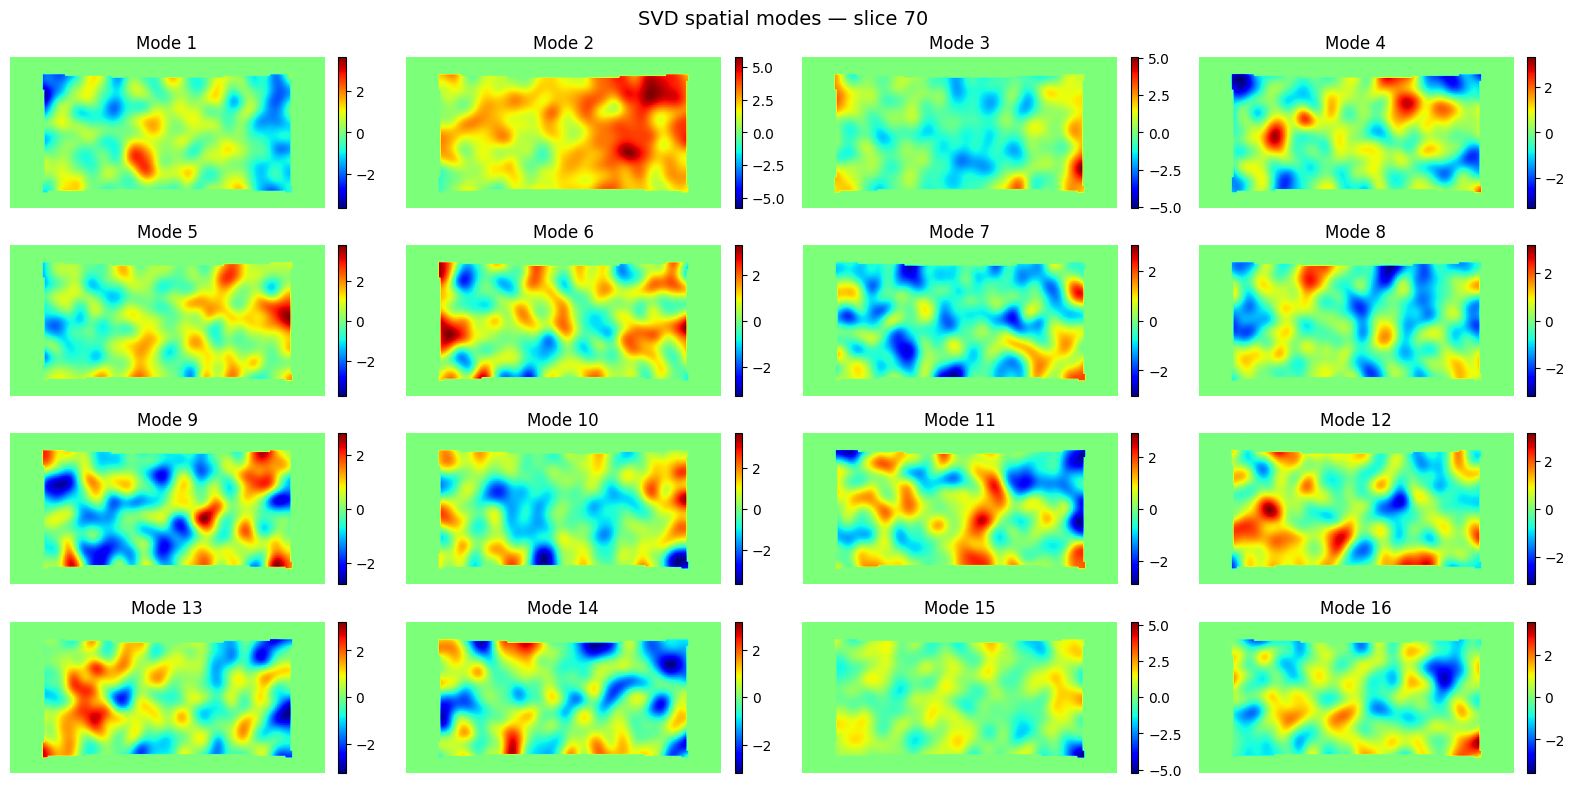

Top 16 SVD modes saved as NIfTI files.


In [18]:
slice_idx = nz // 2
n_modes = 16

fig, axes = plt.subplots(4, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    mode_slice = US_vol[:, :, slice_idx, i]
    vmax = np.max(np.abs(mode_slice))
    im = ax.imshow(mode_slice.T, origin="lower", cmap="jet", vmin=-vmax, vmax=vmax)
    ax.set_title(f"Mode {i + 1}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"SVD spatial modes — slice {slice_idx}", fontsize=14)
plt.tight_layout()
plt.show()

# Save top n_modes as NIfTI volumes
for i in range(n_modes):
    mode_img = nib.Nifti1Image(US_vol[:, :, :, i], affine)
    mode_img.to_filename(BASE / f"svd_mode_{i + 1:02d}.nii.gz")
print(f"Top {n_modes} SVD modes saved as NIfTI files.")

## SVD temporal signatures

Right singular vectors (rows of `Vt`) — the temporal pattern that goes with
each spatial mode.

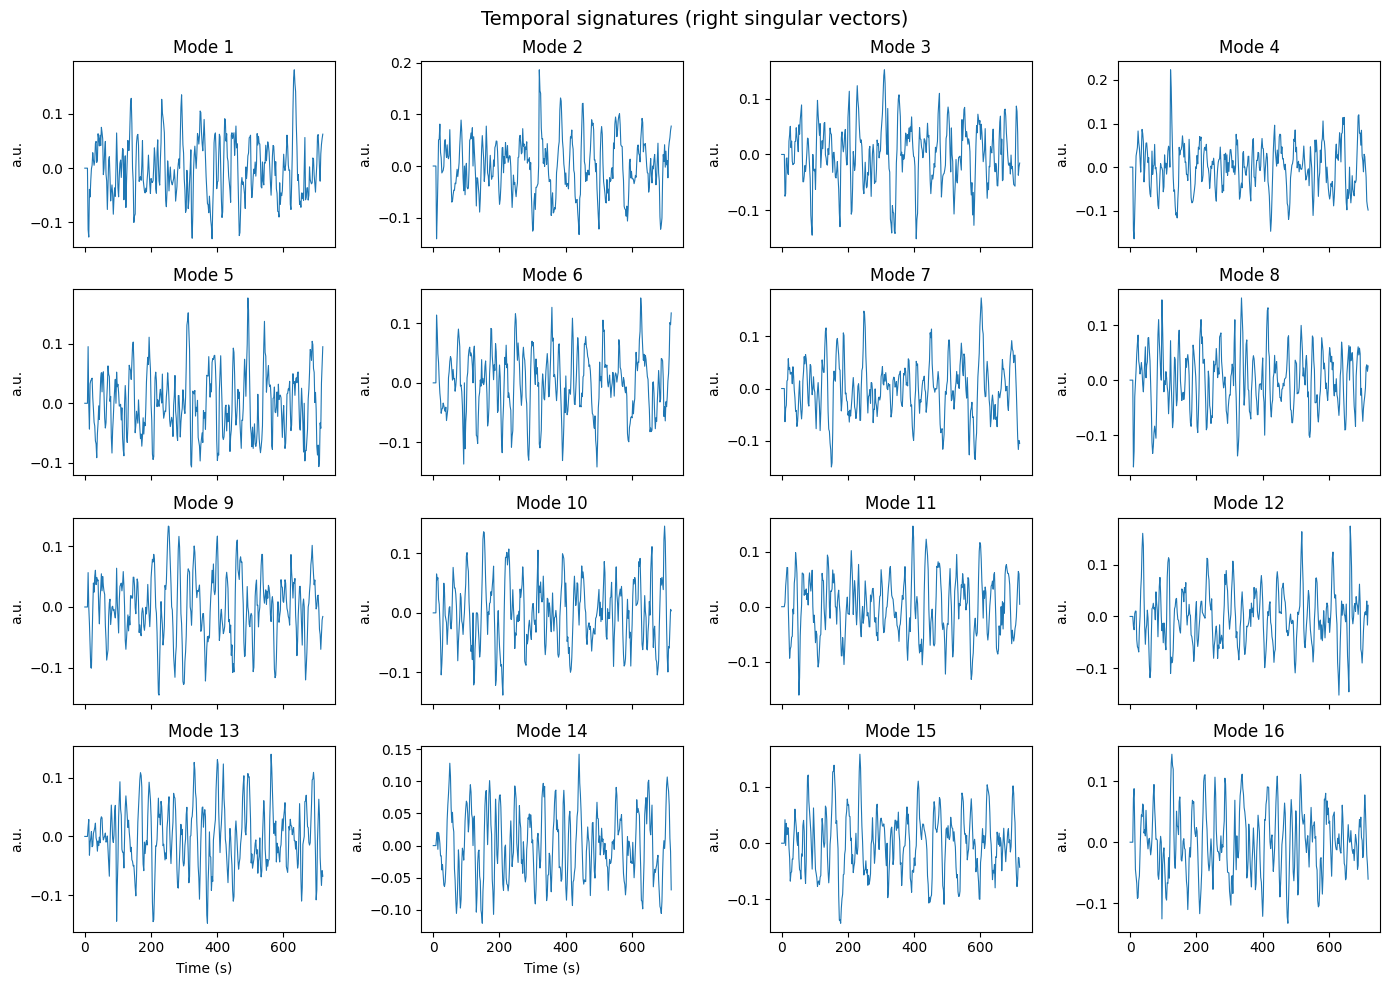

In [19]:
time = np.arange(nt) * t_r

fig, axes = plt.subplots(4, 4, figsize=(14, 10), sharex=True)
for i, ax in enumerate(axes.flat):
    ax.plot(time, Vt[i, :], linewidth=0.8)
    ax.set_title(f"Mode {i + 1}")
    ax.set_ylabel("a.u.")
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Temporal signatures (right singular vectors)", fontsize=14)
plt.tight_layout()
plt.show()

## Seed-based connectivity analysis

Pick a seed voxel (e.g. from a high-z-score location in freeview) and extract
the average time-course over a small cube around it.

Seed time-course shape: (360,)
Saved to: /Users/clairenastaskin/data/sub-Forest001/2026-05-27/pathfinder.forest/events/resting_state/06a173f4-385f-712a-8000-ed6162964365/seed_tc_x93_y33_z12_r2.npy


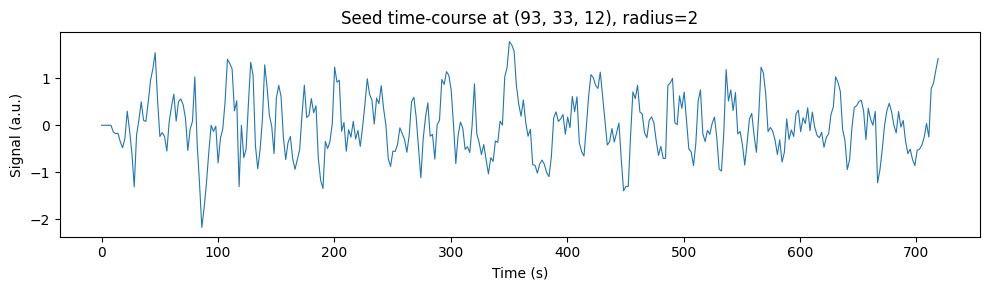

In [20]:
# Seed coordinate (x, y, z) and cube half-side (in voxels)
seed_coord = (93, 33, 12)
radius = 2

x0, y0, z0 = seed_coord
seed_block = data_norm[
    x0 - radius:x0 + radius + 1,
    y0 - radius:y0 + radius + 1,
    z0 - radius:z0 + radius + 1,
    :,
]
seed_tc = seed_block.mean(axis=(0, 1, 2))

seed_tc_path = BASE / f"seed_tc_x{x0}_y{y0}_z{z0}_r{radius}.npy"
np.save(seed_tc_path, seed_tc)
print(f"Seed time-course shape: {seed_tc.shape}")
print(f"Saved to: {seed_tc_path}")

plt.figure(figsize=(10, 3))
plt.plot(np.arange(nt) * t_r, seed_tc, linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Signal (a.u.)")
plt.title(f"Seed time-course at {seed_coord}, radius={radius}")
plt.tight_layout()
plt.show()

## Correlation map

Pearson correlation between the seed time-course and every voxel, computed
as the mean of the product of z-scored time-courses.

In [21]:
# Pearson r without materializing a full-volume z-scored copy.
# data_norm is already demeaned per voxel, so cov(seed, voxel) = ⟨voxel, seed_demean⟩.
seed_demean   = (seed_tc - seed_tc.mean()).astype(np.float32)
seed_norm_val = float(np.linalg.norm(seed_demean))

num         = np.einsum("xyzt,t->xyz", data_norm, seed_demean)   # numerator
voxel_norm  = np.linalg.norm(data_norm, axis=-1)                 # ‖voxel‖
corr_map    = num / (voxel_norm * seed_norm_val + 1e-12)
corr_map    = np.where(mask, corr_map, np.nan)

del num, voxel_norm
gc.collect()

print(f"Correlation map shape: {corr_map.shape}")
print(f"r range (within mask): [{np.nanmin(corr_map):.3f}, {np.nanmax(corr_map):.3f}]")

Correlation map shape: (183, 88, 141)
r range (within mask): [-0.378, 0.998]


## Visualize and save the correlation map

Three orthogonal slices through the seed plus a NIfTI on disk.

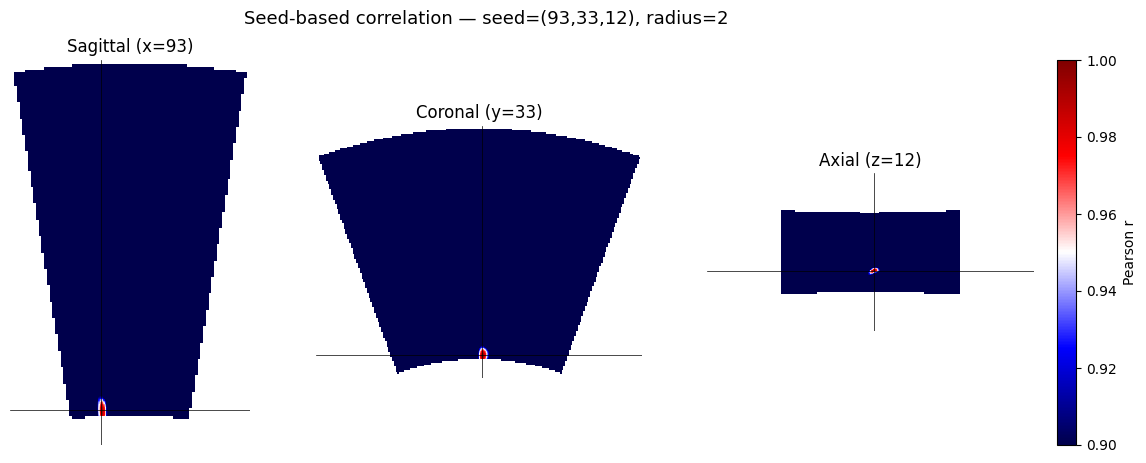

Correlation map saved to: /Users/clairenastaskin/data/sub-Forest001/2026-05-27/pathfinder.forest/events/resting_state/06a173f4-385f-712a-8000-ed6162964365/seed_corr_x93_y33_z12_r2.nii.gz


In [22]:
vmin, vmax = 0.9, 1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(corr_map[x0, :, :].T, origin="lower", cmap="seismic", vmin=vmin, vmax=vmax)
axes[0].axhline(z0, color="k", lw=0.5); axes[0].axvline(y0, color="k", lw=0.5)
axes[0].set_title(f"Sagittal (x={x0})")

axes[1].imshow(corr_map[:, y0, :].T, origin="lower", cmap="seismic", vmin=vmin, vmax=vmax)
axes[1].axhline(z0, color="k", lw=0.5); axes[1].axvline(x0, color="k", lw=0.5)
axes[1].set_title(f"Coronal (y={y0})")

im = axes[2].imshow(corr_map[:, :, z0].T, origin="lower", cmap="seismic", vmin=vmin, vmax=vmax)
axes[2].axhline(y0, color="k", lw=0.5); axes[2].axvline(x0, color="k", lw=0.5)
axes[2].set_title(f"Axial (z={z0})")

for ax in axes:
    ax.axis("off")

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="Pearson r")
fig.suptitle(f"Seed-based correlation — seed=({x0},{y0},{z0}), radius={radius}", fontsize=13)
plt.show()

corr_save = np.nan_to_num(corr_map, nan=0.0).astype(np.float32)
corr_img = nib.Nifti1Image(corr_save, affine)
corr_path = BASE / f"seed_corr_x{x0}_y{y0}_z{z0}_r{radius}.nii.gz"
corr_img.to_filename(corr_path)
print(f"Correlation map saved to: {corr_path}")
